### Building a simple income regression model and a loan classification model.

In [48]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import scipy.stats as stats
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score, root_mean_squared_error
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.feature_selection import SequentialFeatureSelector

In [49]:
# Import the dataset
df = pd.read_csv("../data_files/loan_data.csv")

In [50]:
# Introspect the dataset
df.head()

,person_age,person_gender,person_education,person_income,person_emp_exp,person_home_ownership,loan_amnt,loan_intent,loan_int_rate,loan_percent_income,cb_person_cred_hist_length,credit_score,previous_loan_defaults_on_file,loan_status
0,22.0,female,Master,71948.0,0,RENT,35000.0,PERSONAL,16.02,0.49,3.0,561,No,1
1,21.0,female,High School,12282.0,0,OWN,1000.0,EDUCATION,11.14,0.08,2.0,504,Yes,0
2,25.0,female,High School,12438.0,3,MORTGAGE,5500.0,MEDICAL,12.87,0.44,3.0,635,No,1
3,23.0,female,Bachelor,79753.0,0,RENT,35000.0,MEDICAL,15.23,0.44,2.0,675,No,1
4,24.0,male,Master,66135.0,1,RENT,35000.0,MEDICAL,14.27,0.53,4.0,586,No,1


In [51]:
# Introspect the attributes and datatypes
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45000 entries, 0 to 44999
Data columns (total 14 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   person_age                      45000 non-null  float64
 1   person_gender                   45000 non-null  str    
 2   person_education                45000 non-null  str    
 3   person_income                   45000 non-null  float64
 4   person_emp_exp                  45000 non-null  int64  
 5   person_home_ownership           45000 non-null  str    
 6   loan_amnt                       45000 non-null  float64
 7   loan_intent                     45000 non-null  str    
 8   loan_int_rate                   45000 non-null  float64
 9   loan_percent_income             45000 non-null  float64
 10  cb_person_cred_hist_length      45000 non-null  float64
 11  credit_score                    45000 non-null  int64  
 12  previous_loan_defaults_on_file  45000 non-n

### DATA CLEANING

In [52]:
# Remove unrealistic datapoints
df = df[(df["person_age"] <= 80) & (df["person_emp_exp"] <= df["person_age"])]

### EXPLORATORY ANALYSIS TO UNDERSTAND THE DATA.

In [53]:
# Check for missing values
df.isna().sum()

person_age                        0
person_gender                     0
person_education                  0
person_income                     0
person_emp_exp                    0
person_home_ownership             0
loan_amnt                         0
loan_intent                       0
loan_int_rate                     0
loan_percent_income               0
cb_person_cred_hist_length        0
credit_score                      0
previous_loan_defaults_on_file    0
loan_status                       0
dtype: int64

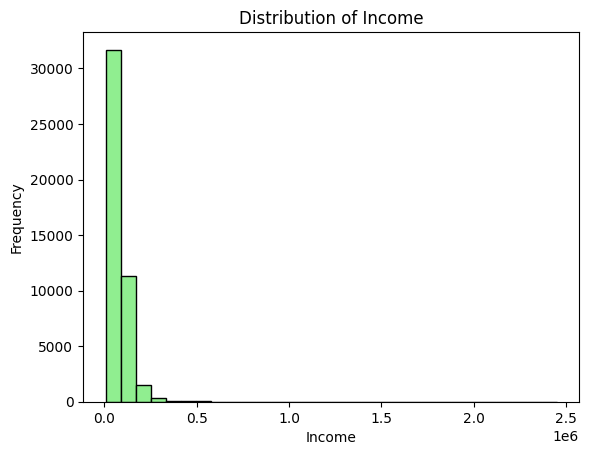

In [54]:
# Distribution of target variable (income)
plt.hist(df["person_income"], bins=30, color="lightgreen", edgecolor="black")
plt.title("Distribution of Income")
plt.xlabel("Income")
plt.ylabel("Frequency")
plt.show()

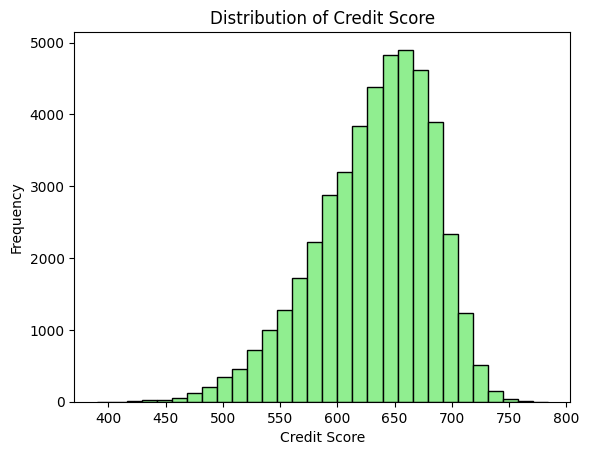

In [55]:
# Distribution of credit score
plt.hist(df["credit_score"], bins=30, color="lightgreen", edgecolor="black")
plt.title("Distribution of Credit Score")
plt.xlabel("Credit Score")
plt.ylabel("Frequency")
plt.show()

/var/folders/qf/s48qgw497z13pg4r1vtm2qph0000gn/T/ipykernel_62367/465846322.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x="loan_status", data=df_plot, edgecolor="black", palette="Set2", order=["Paid", "Default"])


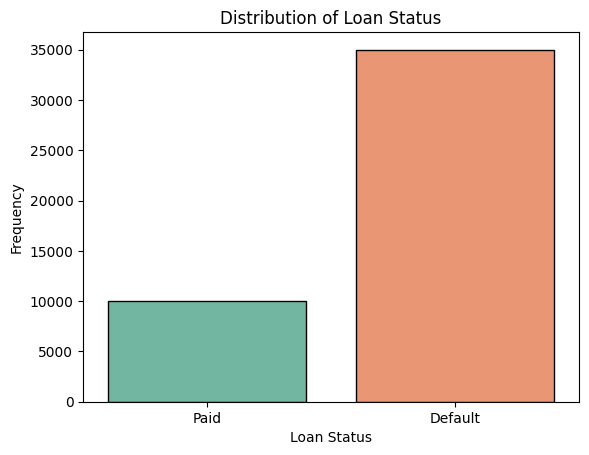

In [56]:
# Plot loan distribution status
df_plot = df.copy()
df_plot["loan_status"] = df_plot["loan_status"].map({0: "Default", 1: "Paid"})

sns.countplot(x="loan_status", data=df_plot, edgecolor="black", palette="Set2", order=["Paid", "Default"])
plt.title("Distribution of Loan Status")
plt.xlabel("Loan Status")
plt.ylabel("Frequency")
plt.show()

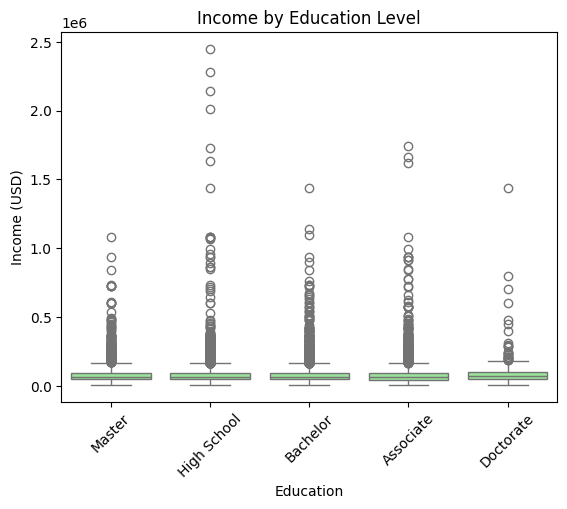

In [57]:
# Boxplot showing distribution of education and income
sns.boxplot(x="person_education", y="person_income", data=df, color="lightgreen")
plt.title("Income by Education Level")
plt.xlabel("Education")
plt.ylabel("Income (USD)")
plt.xticks(rotation=45)
plt.show()

### DATA PREPROCESSING APPLIED TO SPLIT DATA TO AVOID DATA LEAKAGE


In [58]:
# Deterministic ordinal encoding for education level
df["person_education"] = df["person_education"].map({
    "High School": 1, "Associate": 2, "Bachelor": 3, "Master": 4, "Doctorate": 5
})

In [59]:
# Drop columns that would cause leakage:
# loan_percent_income  = loan_amnt / person_income — arithmetically encodes the target.
#                        A model can back-calculate income from it. Target leakage.
# loan_status          = whether the borrower eventually defaulted — a post-repayment outcome.
#                        Unknown at the time you would want to predict income.
#                        Keeping it would mean the model learns from information it cannot
#                        have in production. Temporal / downstream leakage.

cols_to_drop = ["person_income", "loan_percent_income", "loan_status"]

X = df.drop(columns=cols_to_drop)
Y = df["person_income"]

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.3, random_state=42)

In [60]:
# Clip data after split to avoid leakage
lower = Y_train.quantile(0.01)
upper = Y_train.quantile(0.99)

Y_train = Y_train.clip(lower=lower, upper=upper)
Y_test  = Y_test.clip(lower=lower, upper=upper)

In [61]:
# Encode categorical variables with LabelEncoder
cols_to_encode = ["person_gender", "person_home_ownership", "loan_intent",
                  "previous_loan_defaults_on_file"]

le_encoders = {}
for col in cols_to_encode:
    le = LabelEncoder()
    X_train[col] = le.fit_transform(X_train[col])
    X_test[col]  = le.transform(X_test[col])
    le_encoders[col] = le


In [62]:
# selecting model
model_lm = LinearRegression()

# train model
model_lm.fit(X_train, Y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


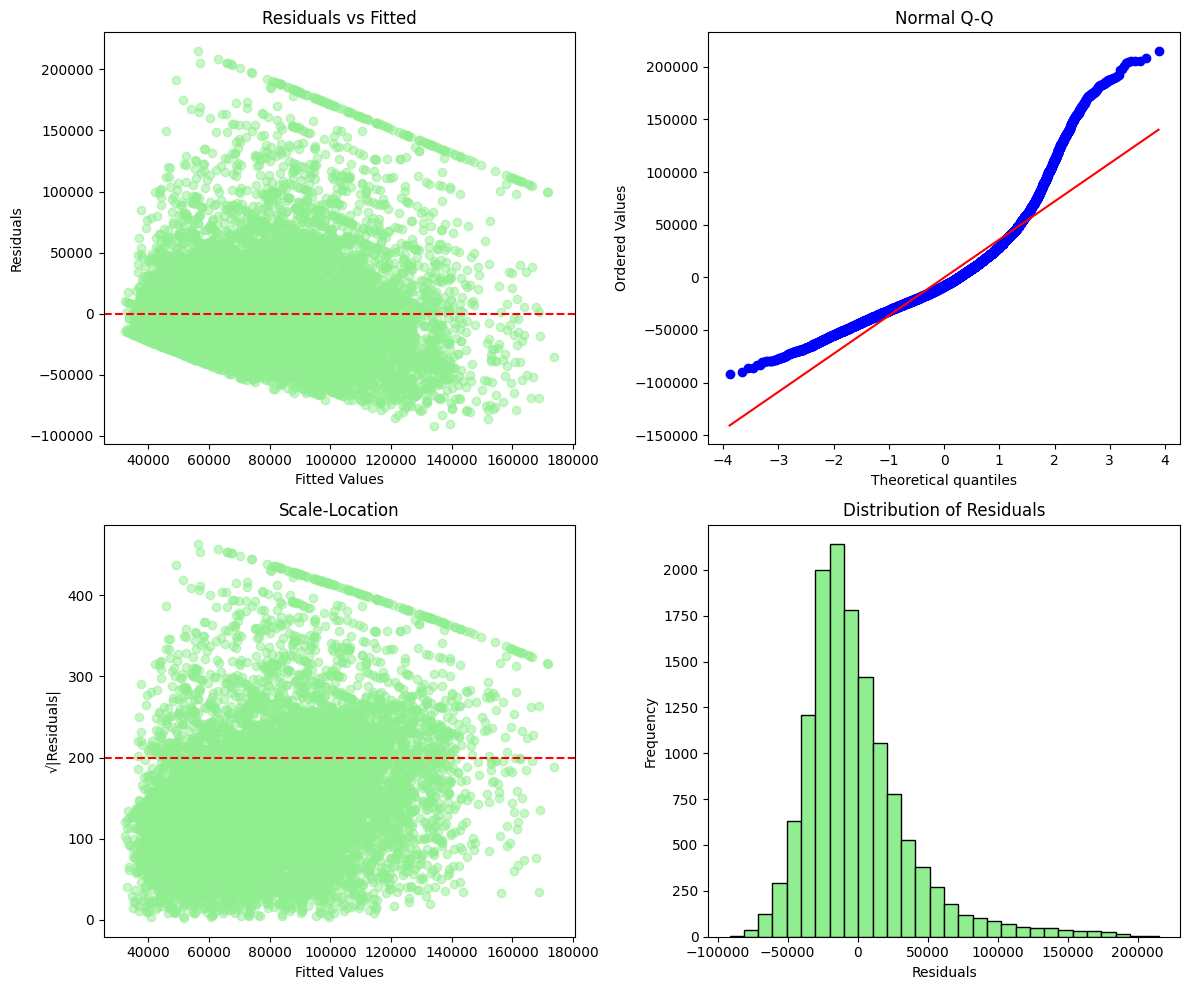

In [63]:
# Get predictions and residuals
y_pred    = model_lm.predict(X_test)
residuals = Y_test - y_pred

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Fitted — checks Linearity
axes[0, 0].scatter(y_pred, residuals, alpha=0.5, color="lightgreen")
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals vs Fitted")
axes[0, 0].set_xlabel("Fitted Values")
axes[0, 0].set_ylabel("Residuals")

# Q-Q Plot — checks Normality
stats.probplot(residuals, plot=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q")

# Scale-Location — checks Homoscedasticity
axes[1, 0].scatter(y_pred, np.sqrt(np.abs(residuals)), alpha=0.5, color="lightgreen")
axes[1, 0].axhline(200, color="red", linestyle="--")
axes[1, 0].set_title("Scale-Location")
axes[1, 0].set_xlabel("Fitted Values")
axes[1, 0].set_ylabel("\u221a|Residuals|")

# Residuals histogram — checks Normality of errors
axes[1, 1].hist(residuals, bins=30, color="lightgreen", edgecolor="black")
axes[1, 1].set_title("Distribution of Residuals")
axes[1, 1].set_xlabel("Residuals")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [64]:
# Log transformation
X_train_log = X_train.copy()
X_test_log  = X_test.copy()
Y_train_log = np.log(Y_train)
Y_test_log  = np.log(Y_test)

In [65]:
# Train the log model
model_lm_log = LinearRegression()
model_lm_log.fit(X_train_log, Y_train_log)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


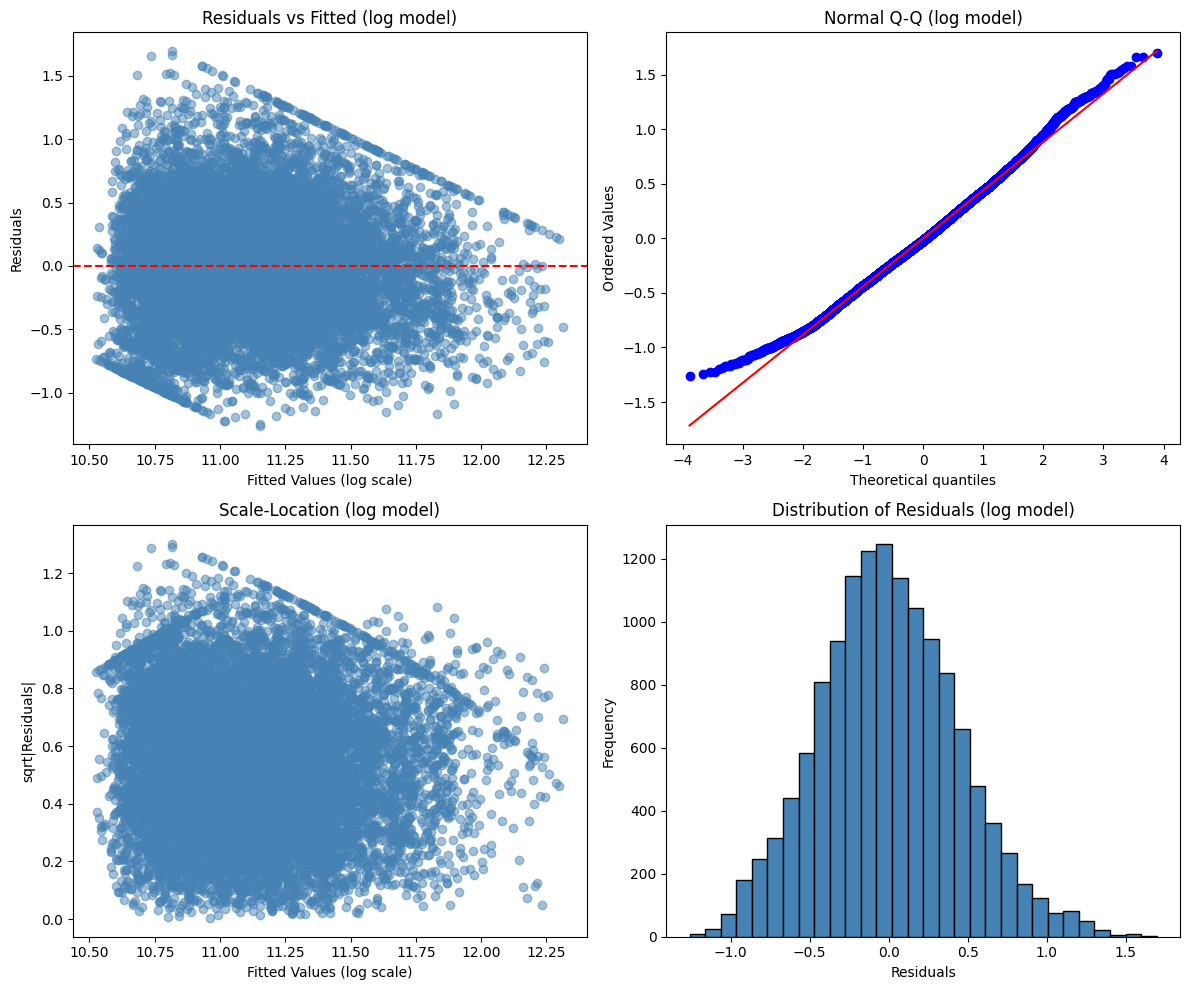

In [66]:
y_pred_log    = model_lm_log.predict(X_test_log)
residuals_log = Y_test_log - y_pred_log

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Residuals vs Fitted
axes[0, 0].scatter(y_pred_log, residuals_log, alpha=0.5, color="steelblue")
axes[0, 0].axhline(0, color="red", linestyle="--")
axes[0, 0].set_title("Residuals vs Fitted (log model)")
axes[0, 0].set_xlabel("Fitted Values (log scale)")
axes[0, 0].set_ylabel("Residuals")

# Normal Q-Q
stats.probplot(residuals_log, plot=axes[0, 1])
axes[0, 1].set_title("Normal Q-Q (log model)")

# Scale-Location
axes[1, 0].scatter(y_pred_log, np.sqrt(np.abs(residuals_log)), alpha=0.5, color="steelblue")
axes[1, 0].set_title("Scale-Location (log model)")
axes[1, 0].set_xlabel("Fitted Values (log scale)")
axes[1, 0].set_ylabel("sqrt|Residuals|")

# Residuals histogram
axes[1, 1].hist(residuals_log, bins=30, color="steelblue", edgecolor="black")
axes[1, 1].set_title("Distribution of Residuals (log model)")
axes[1, 1].set_xlabel("Residuals")
axes[1, 1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

In [67]:
# Compare performance metrics

r2_orig   = r2_score(Y_test, model_lm.predict(X_test))
rmse_orig = root_mean_squared_error(Y_test, model_lm.predict(X_test))

r2_log   = r2_score(Y_test_log, y_pred_log)
rmse_log = root_mean_squared_error(Y_test_log, y_pred_log)        

print(f"Original model  ->  R2: {r2_orig:.4f} | RMSE: {rmse_orig:,.2f}")
print(f"Log model       ->  R2: {r2_log:.4f}  | RMSE: {rmse_log:.4f} (log scale)")

Original model  ->  R2: 0.2640 | RMSE: 38,450.40
Log model       ->  R2: 0.3095  | RMSE: 0.4421 (log scale)


In [68]:
# Feature engineered model with log transformation and feature selection
base_engine = LinearRegression()

# Forward Stepwise Selector
sfs = SequentialFeatureSelector(
    estimator=base_engine,
    n_features_to_select='auto',
    direction='forward',
    scoring='neg_mean_squared_error',
    cv=5
)

sfs.fit(X_train_log, Y_train_log)

# Get the selected features
best_columns = X_train_log.columns[sfs.get_support()]
print("Features Selected:", list(best_columns))

X_train_best = X_train_log[best_columns]
X_test_best  = X_test_log[best_columns]

# Build and train a new model using selected features
final_log_model = LinearRegression()
final_log_model.fit(X_train_best, Y_train_log)

# Evaluate
y_pred_new = final_log_model.predict(X_test_best)

r2_new   = r2_score(Y_test_log, y_pred_new)
rmse_new = root_mean_squared_error(Y_test_log, y_pred_new)

print(f"New Feature Selected Log Model ->  R2: {r2_new:.4f} | RMSE: {rmse_new:.4f}")

Features Selected: ['person_age', 'person_home_ownership', 'loan_amnt', 'credit_score', 'previous_loan_defaults_on_file']
New Feature Selected Log Model ->  R2: 0.3085 | RMSE: 0.4425
